## 베이직반 통계 1차시 복습퀴즈 

### Baseline (주어진 코드)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [4]:
folder_path = "h&m dataset" #########--------------------- 자기 경로로 수정하기!
article_df = pd.read_csv(folder_path+"/articles_hm.csv")
customer_df = pd.read_csv(folder_path+"/customer_hm.csv")
transaction_df = pd.read_csv(folder_path+"/transactions_hm.csv")

In [5]:
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df[['t_dat','customer_id','Active','age','section_no','section_name','index_group_no','index_group_name','product_type_no','product_type_name','price']].copy()
df['price'] = df['price']*1000

In [6]:
df

,t_dat,customer_id,Active,age,section_no,section_name,index_group_no,index_group_name,product_type_no,product_type_name,price
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,1,51,53,Divided Collection,2,Divided,252,Sweater,16.93
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,0,28,6,Womens Casual,1,Ladieswear,254,Top,33.88
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,1,37,21,Contemporary Casual,3,Menswear,274,Shorts,16.93
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,0,19,65,Womens Big accessories,1,Ladieswear,66,Bag,33.88
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,0,35,26,Men Underwear,3,Menswear,302,Socks,3.22
...,...,...,...,...,...,...,...,...,...,...,...
812926,2019-03-25,8e900818a1da0e73300a012794615993fbefb43f851430...,0,21,15,Womens Everyday Collection,1,Ladieswear,273,Leggings/Tights,25.41
812927,2019-10-18,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,1,39,15,Womens Everyday Collection,1,Ladieswear,265,Dress,16.93
812928,2019-04-06,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,1,44,56,Denim Men,3,Menswear,272,Trousers,21.73
812929,2019-03-20,3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...,0,51,16,Womens Everyday Basics,1,Ladieswear,272,Trousers,16.93


- t_dat : 날짜, 이산형
- customer_id : 명목형 
- active : 이산형 --> 명목형! (0과 1)
- age : 이산형 
- section_no : 이산형 --> 명목형 (새우깡 과자 이름에 숫자 할당된 것처럼 숫자에 의미가 없으므로 순서형 아니고 명목형)
- section_name : 명목형 
- index_group_no : 명목형
- index_group_name : 명목형 
- product_type_no : 명목형 
- product_type_name : 명목형 
- price : 연속형 

## 1번문제
### 명목형, 순위형 등 질적데이터에 해당하는 컬럼들
### 답 : Active, section_no, index_group_no, product_type_no

## 2번문제
### 이산형 데이터에 해당하는 컬럼들
### 답 : age

## 3번문제 
### price의 히스토그램을 해석한 결과로 옳은 것은?
### 답 : price의 중앙값이 평균값보다 작다

<Axes: >

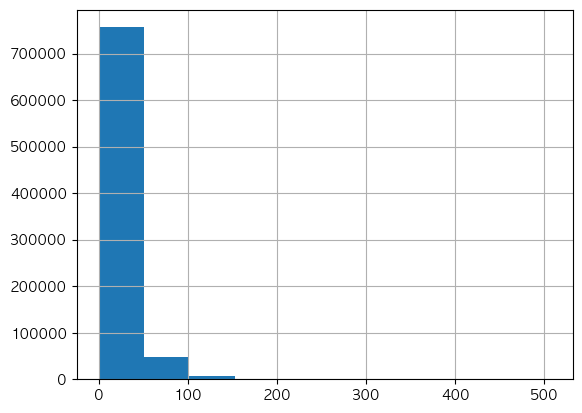

In [8]:
df['price'].hist()

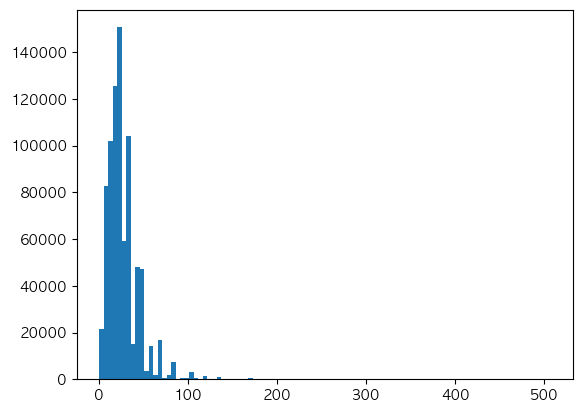

In [10]:
plt.hist(df['price'], bins= 100)
plt.show()

In [ ]:
df['price'].describe()
# mean : 27.77
# median : 25.40

count   812931.00
mean        27.77
std         19.32
min          0.24
25%         15.24
50%         25.41
75%         33.88
max        506.78
Name: price, dtype: float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812931 entries, 0 to 812930
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   t_dat              812931 non-null  object 
 1   customer_id        812931 non-null  object 
 2   Active             812931 non-null  int64  
 3   age                812931 non-null  int64  
 4   section_no         812931 non-null  int64  
 5   section_name       812931 non-null  object 
 6   index_group_no     812931 non-null  int64  
 7   index_group_name   812931 non-null  object 
 8   product_type_no    812931 non-null  int64  
 9   product_type_name  812931 non-null  object 
 10  price              812931 non-null  float64
dtypes: float64(1), int64(5), object(5)
memory usage: 68.2+ MB


## 7번문제
### price를 iqr 방식으로 처리했을 때, 이상치로 분류되는 데이터의 행 개수는 몇개일까요?


In [13]:
df['price'].isna().sum()

np.int64(0)

In [19]:
price = df['price'].values 
q1 = np.percentile(price, 25)
q3 = np.percentile(price, 75)
iqr = q3 - q1 
print(q1, q3, iqr)

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
outlier = price[(price>upper) | (price<lower)]
print(len(price))
print(len(outlier))

15.237288 33.881356000000004 18.644068000000004
812931
38557
